In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Data Preparation:

In [8]:
xls = pd.ExcelFile("heart_disease.xlsx")
xls.sheet_names

['Description', 'Heart_disease']

In [13]:
df = pd.read_excel("heart_disease.xlsx", sheet_name = "Heart_disease")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


## 2. Exploratory Data Analysis (EDA):

In [15]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [16]:
# check missing values:

df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [17]:
# handle missing value in 'Oldpeak' :

df['oldpeak'].fillna(df['oldpeak'].median(), inplace = True)

/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/ipykernel_21887/2912011411.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace = True)


In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
# check for duplicates :
df.duplicated().sum()

np.int64(1)

In [21]:
# handle duplicates
df.drop_duplicates(inplace = True)

In [22]:
df.duplicated().sum()

np.int64(0)

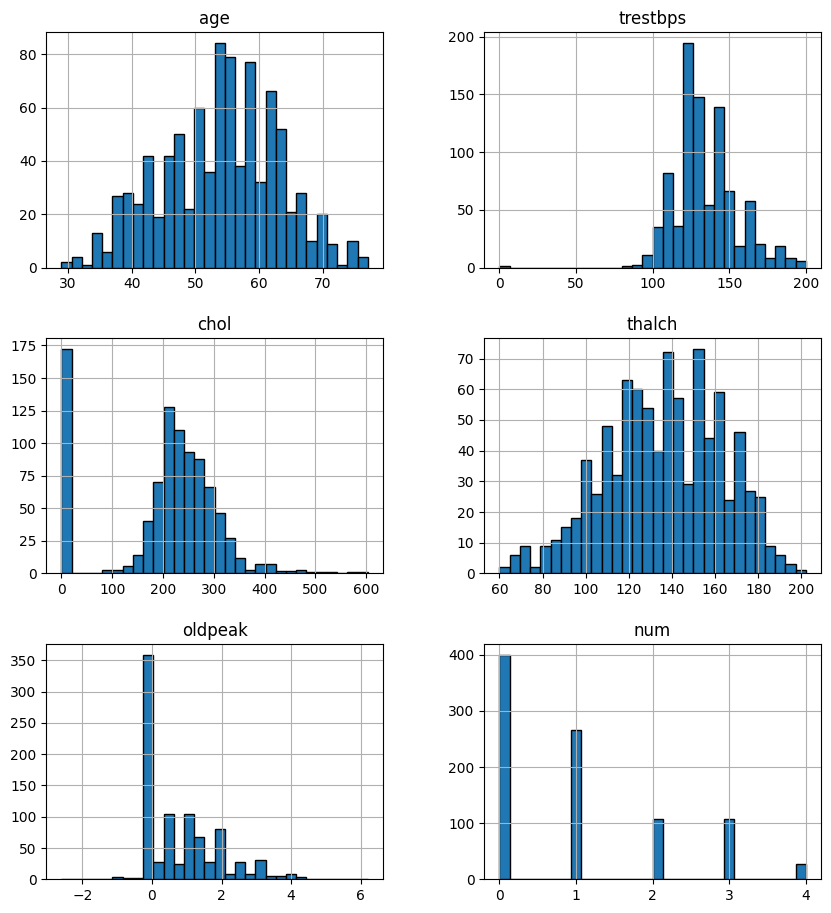

In [35]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# visualization:
        # histogram
df.hist(bins = 30 , figsize=(10,11) , edgecolor = "black")

plt.show()

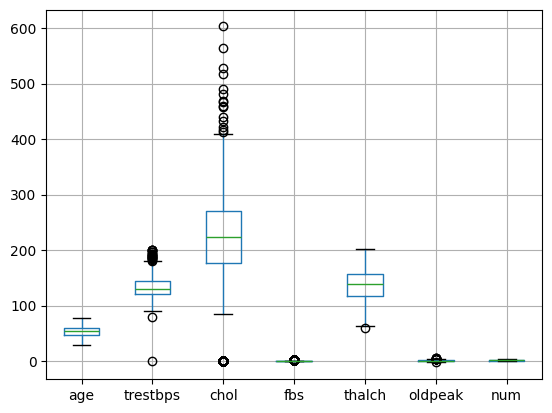

In [36]:
        # boxplot
df.boxplot()
plt.show()

In [38]:
            # handle outliers
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Treat (cap) outliers
    df[col] = df[col].clip(lower, upper)

print("Outliers detected and treated successfully.")

Outliers detected and treated successfully.


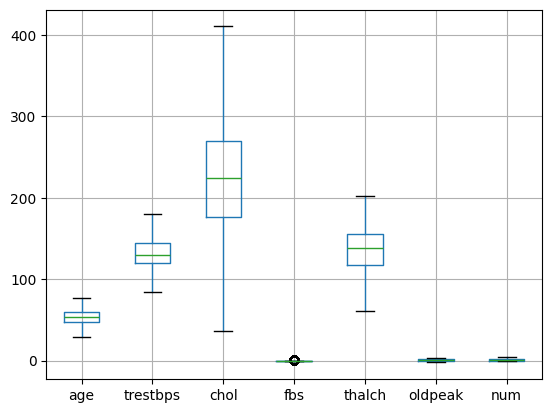

In [39]:
df.boxplot()
plt.show()

In [40]:
        # correlation
corr = df.corr(numeric_only = True)
corr

,age,trestbps,chol,fbs,thalch,oldpeak,num
age,1.000000,0.261741,-0.092618,0.177004,-0.327919,0.221335,0.326227
trestbps,0.261741,1.000000,0.126318,0.113043,-0.131224,0.142701,0.141934
chol,-0.092618,0.126318,1.000000,-0.112193,0.194884,0.033985,-0.228771
fbs,0.177004,0.113043,-0.112193,1.000000,-0.065856,0.011430,0.156839
thalch,-0.327919,-0.131224,0.194884,-0.065856,1.000000,-0.115995,-0.322633
oldpeak,0.221335,0.142701,0.033985,0.011430,-0.115995,1.000000,0.407176
num,0.326227,0.141934,-0.228771,0.156839,-0.322633,0.407176,1.000000


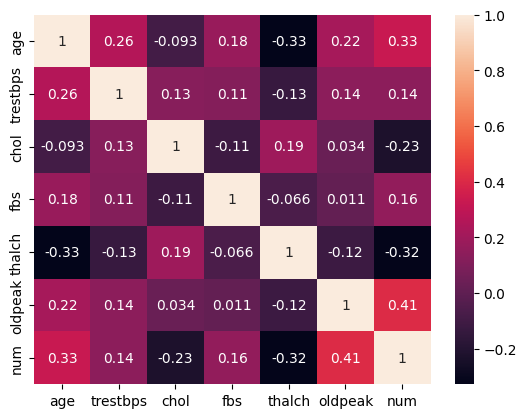

In [42]:
        # heatmap 

sns.heatmap(corr, annot = True)
plt.show()

## 3. Feature Engineering:

In [43]:
cat_cols=df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    print(f"{col}:{df[col].nunique()} unique values")

sex:2 unique values
cp:4 unique values
restecg:3 unique values
exang:4 unique values
slope:3 unique values
thal:3 unique values


In [44]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233.0,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203.0,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192.0,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186.0,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201.0,False,normal,126,True,1.5,flat,fixed defect,0


In [46]:
df['exang'].unique()

array([False, True, 'FALSE', 'TURE'], dtype=object)

In [47]:
df=pd.get_dummies(df, columns=['sex','exang'], drop_first=True)
df= pd.get_dummies(df, columns=['thal'], prefix='thal')

In [48]:
from sklearn.preprocessing import OrdinalEncoder
category_order = ['asymptomatic', 'non-anginal', 'atypical angina', 'typical angina']
encoder = OrdinalEncoder(categories=[category_order])
df['cp'] = encoder.fit_transform(df[['cp']])

In [49]:
category_order = ['upsloping', 'flat', 'downsloping']
encoder = OrdinalEncoder(categories=[category_order])
df['slope'] = encoder.fit_transform(df[['slope']])

In [50]:
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,oldpeak,slope,num,sex_Male,exang_True,exang_FALSE,exang_TURE,thal_fixed defect,thal_normal,thal_reversable defect
0,63,3.0,145,233.0,True,lv hypertrophy,150,2.3,2.0,0,True,False,False,False,True,False,False
1,41,2.0,135,203.0,False,normal,132,0.0,1.0,0,True,False,False,False,True,False,False
2,57,0.0,140,192.0,False,normal,148,0.4,1.0,0,True,False,False,False,True,False,False
3,52,3.0,118,186.0,False,lv hypertrophy,190,0.0,1.0,0,True,False,False,False,True,False,False
4,57,0.0,110,201.0,False,normal,126,1.5,1.0,0,True,True,False,False,True,False,False


In [51]:
category_order = [ 'normal', 'st-t abnormality','lv hypertrophy']
encoder = OrdinalEncoder(categories=[category_order])
df['restecg'] = encoder.fit_transform(df[['restecg']])

In [52]:
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,oldpeak,slope,num,sex_Male,exang_True,exang_FALSE,exang_TURE,thal_fixed defect,thal_normal,thal_reversable defect
0,63,3.0,145,233.0,True,2.0,150,2.3,2.0,0,True,False,False,False,True,False,False
1,41,2.0,135,203.0,False,0.0,132,0.0,1.0,0,True,False,False,False,True,False,False
2,57,0.0,140,192.0,False,0.0,148,0.4,1.0,0,True,False,False,False,True,False,False
3,52,3.0,118,186.0,False,2.0,190,0.0,1.0,0,True,False,False,False,True,False,False
4,57,0.0,110,201.0,False,0.0,126,1.5,1.0,0,True,True,False,False,True,False,False


In [53]:
# since we are using decision tree algorithm scaling is not necessary

## 4. Decision Tree Classification:

In [55]:
# taking num as target
# since num has a lot og unique values , setting it only as 2 healthy and heart disease
# Convert multi-class to binary

df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
y = df['num']
x = df.drop('num', axis=1)



In [56]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (e.g., using an 80-20 split).

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [58]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
# create model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
# evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-Score:", round(f1, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.714
Precision: 0.716
Recall: 0.714
F1-Score: 0.715

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.70      0.68        80
           1       0.76      0.73      0.74       102

    accuracy                           0.71       182
   macro avg       0.71      0.71      0.71       182
weighted avg       0.72      0.71      0.71       182


Confusion Matrix:
 [[56 24]
 [28 74]]


In [64]:
# roc 
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.7127450980392156)

## 5. Hyperparameter Tuning:

In [66]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [67]:
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                  
    scoring='accuracy',     
    n_jobs=-1               
)

In [68]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 9, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [69]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.7613793103448276


In [70]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

## 6. Model Evaluation and Analysis:

In [72]:
# generate predictions 
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7197802197802198

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.74      0.70        80
           1       0.77      0.71      0.74       102

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.73      0.72      0.72       182



In [73]:
# Roc-AUC score
y_prob = best_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.781


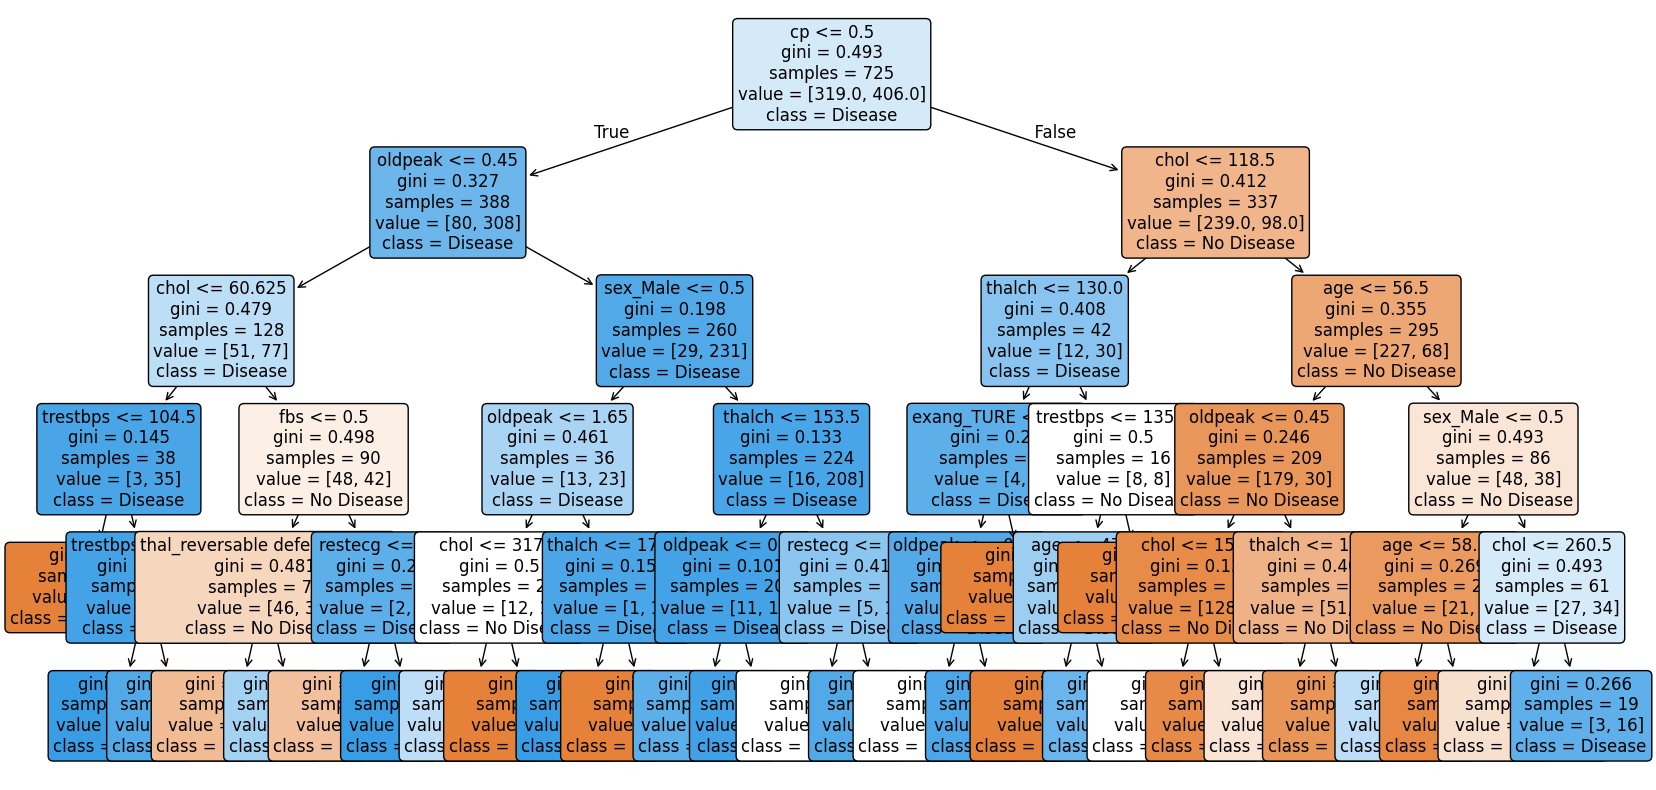

In [74]:
# plot tree
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
tree.plot_tree(
    best_model, 
    feature_names=X_train.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()

In [75]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                   Feature  Importance
1                       cp    0.451691
3                     chol    0.177469
7                  oldpeak    0.110036
0                      age    0.076207
9                 sex_Male    0.053478
6                   thalch    0.046277
2                 trestbps    0.022951
4                      fbs    0.021660
5                  restecg    0.016492
15  thal_reversable defect    0.016369
12              exang_TURE    0.007370
8                    slope    0.000000
10              exang_True    0.000000
11             exang_FALSE    0.000000
13       thal_fixed defect    0.000000
14             thal_normal    0.000000


1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

    * max_depth controls how deep the tree can grow.
        Higher depth can cause overfitting; lower depth can cause underfitting.
    * min_samples_split sets the minimum samples needed to split a node.
        Larger values make the tree simpler and reduce overfitting.
    * min_samples_leaf sets the minimum samples required in a leaf node.
        Higher values make the model more generalized and stable.
    * criterion decides how the tree measures the best split (e.g., gini or entropy).
      It affects how the tree chooses features to split on.
    * max_features controls how many features are considered when splitting.
        Fewer features increase randomness and reduce overfitting.


2. What is the difference between the Label encoding and One-hot encoding?

    * Label Encoding converts each category into a number 
        -It imposes an order between categories, which may not always be meaningful.
    * One-Hot Encoding creates separate binary columns for each category (e.g., Red → 1 0 0, Blue → 0 1 0).
        -It does not assume any order and is useful when all categories are equally important.
    
    # Label Encoding is best for ordinal data, 
    # while One-Hot Encoding is best for nominal data.